Cell 1: Import Libraries & Load Raw Datasets

In [40]:
import pandas as pd
import numpy as np

# Load all three raw datasets
activity_df = pd.read_csv('dailyActivity_merged.csv')
sleep_df = pd.read_csv('sleepDay_merged.csv')
hourly_steps = pd.read_csv('hourlySteps_merged.csv')

print("All 3 datasets successfully loaded into the workspace!")

All 3 datasets successfully loaded into the workspace!


Cell 2: Initial Inspection (Daily Activity Data)

In [41]:
print("--- Daily Activity Dataset Info ---")
activity_df.info()

print("\n--- First 5 Rows Preview ---")
activity_df.head()

--- Daily Activity Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


Cell 3: Clean Daily Activity Data

In [42]:
# Convert ActivityDate from 'object' to 'datetime'
activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate'], format='%m/%d/%Y')

# Count unique users and duplicates
unique_activity_users = activity_df['Id'].nunique()
activity_duplicates = activity_df.duplicated().sum()

# Drop duplicates
activity_df = activity_df.drop_duplicates()

print(f"Format Fix: 'ActivityDate' type is now {activity_df['ActivityDate'].dtype}")
print(f"Sample Size: There are {unique_activity_users} unique users in this dataset.")
print(f"Duplicates found and removed: {activity_duplicates}")

Format Fix: 'ActivityDate' type is now datetime64[ns]
Sample Size: There are 33 unique users in this dataset.
Duplicates found and removed: 0


Cell 4: Initial Inspection & Clean Sleep Data

In [43]:
print("--- Sleep Dataset Info ---")
sleep_df.info()
print(f"\nInitial Sleep Duplicates: {sleep_df.duplicated().sum()}")

# Remove duplicates and fix the date format
sleep_df = sleep_df.drop_duplicates()
sleep_df['SleepDay'] = pd.to_datetime(sleep_df['SleepDay'], errors='coerce')

# Verify results
print(f"\nCleaned Sleep Duplicates: {sleep_df.duplicated().sum()}")
print(f"Unique users in Sleep dataset: {sleep_df['Id'].nunique()}")

--- Sleep Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB

Initial Sleep Duplicates: 3

Cleaned Sleep Duplicates: 0
Unique users in Sleep dataset: 24


/tmp/ipykernel_4582/2464730191.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_df['SleepDay'] = pd.to_datetime(sleep_df['SleepDay'], errors='coerce')


Cell 5: Initial Inspection (Hourly Steps Data)

In [44]:
print("--- Hourly Steps Info ---")
hourly_steps.info()

print("\n--- Hourly Steps Preview ---")
display(hourly_steps.head())

--- Hourly Steps Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   StepTotal     22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB

--- Hourly Steps Preview ---


,Id,ActivityHour,StepTotal
0,1503960366,4/12/2016 12:00:00 AM,373
1,1503960366,4/12/2016 1:00:00 AM,160
2,1503960366,4/12/2016 2:00:00 AM,151
3,1503960366,4/12/2016 3:00:00 AM,0
4,1503960366,4/12/2016 4:00:00 AM,0


Cell 6: Clean and Feature Engineer Hourly Steps Data

In [45]:
# Convert ActivityHour to datetime
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'], errors='coerce')

# Extract Hour (0-23) and separate Date columns
hourly_steps['Hour'] = hourly_steps['ActivityHour'].dt.hour
hourly_steps['Date'] = hourly_steps['ActivityHour'].dt.date

# Check and drop duplicates
hourly_duplicates = hourly_steps.duplicated().sum()
hourly_steps = hourly_steps.drop_duplicates()

print(f"Format Fix: 'ActivityHour' type is now {hourly_steps['ActivityHour'].dtype}")
print(f"New Columns Added: 'Hour' (0-23) and 'Date'")
print(f"Duplicates found and removed: {hourly_duplicates}")
print(f"Unique users in hourly dataset: {hourly_steps['Id'].nunique()}")

/tmp/ipykernel_4582/3317788268.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'], errors='coerce')


Format Fix: 'ActivityHour' type is now datetime64[ns]
New Columns Added: 'Hour' (0-23) and 'Date'
Duplicates found and removed: 0
Unique users in hourly dataset: 33


Cell 7: Rename Daily Headers and Merge Dataframes

In [46]:
# Rename daily date columns to a standardized name for merging
activity_df = activity_df.rename(columns={'ActivityDate': 'Date'})
sleep_df = sleep_df.rename(columns={'SleepDay': 'Date'})

# Merge daily dataframes using an inner merge
combined_df = pd.merge(activity_df, sleep_df, on=['Id', 'Date'], how='inner')

print("--- Combined Master Dataset Info ---")
combined_df.info()
print(f"\nUnique users in combined daily data: {combined_df['Id'].nunique()}")

--- Combined Master Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        410 non-null    int64         
 1   Date                      410 non-null    datetime64[ns]
 2   TotalSteps                410 non-null    int64         
 3   TotalDistance             410 non-null    float64       
 4   TrackerDistance           410 non-null    float64       
 5   LoggedActivitiesDistance  410 non-null    float64       
 6   VeryActiveDistance        410 non-null    float64       
 7   ModeratelyActiveDistance  410 non-null    float64       
 8   LightActiveDistance       410 non-null    float64       
 9   SedentaryActiveDistance   410 non-null    float64       
 10  VeryActiveMinutes         410 non-null    int64         
 11  FairlyActiveMinutes       410 non-null    int64

Cell 8: Summary Statistics (Transition to Analyze Phase)

In [47]:
# Generate summary statistics for key daily metrics
analysis_summary = combined_df[['TotalSteps', 'VeryActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalMinutesAsleep', 'TotalTimeInBed']].describe()

print("--- Key Daily Metrics Summary Statistics ---")
display(analysis_summary.round(2))

--- Key Daily Metrics Summary Statistics ---


,TotalSteps,VeryActiveMinutes,SedentaryMinutes,Calories,TotalMinutesAsleep,TotalTimeInBed
count,410.00,410.00,410.00,410.00,410.00,410.00
mean,8514.91,25.05,712.10,2389.30,419.17,458.48
std,4157.38,36.22,166.18,758.44,118.64,127.46
min,17.00,0.00,0.00,257.00,58.00,61.00
25%,5188.75,0.00,631.25,1841.00,361.00,403.75
50%,8913.00,9.00,717.00,2207.00,432.50,463.00
75%,11370.25,38.00,782.75,2920.00,490.00,526.00
max,22770.00,210.00,1265.00,4900.00,796.00,961.00


Cell 9: Scatter Plot - Steps vs. Calories Burned

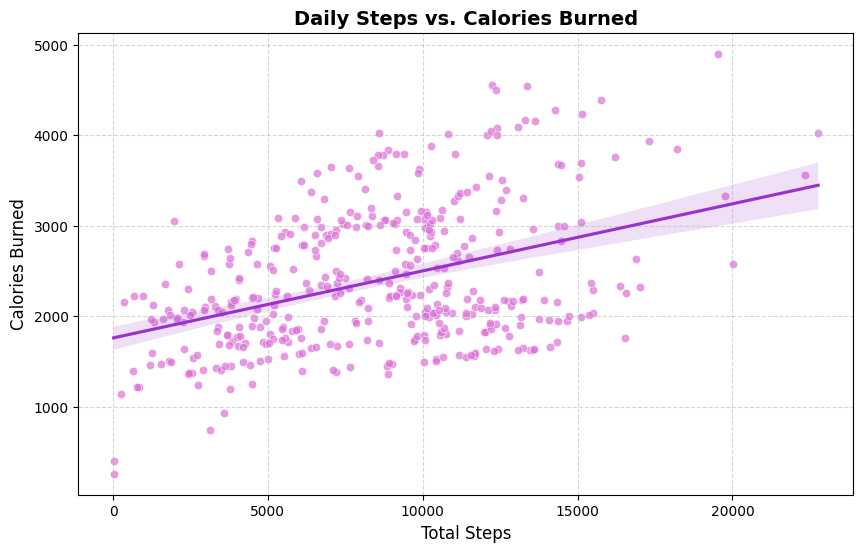

In [48]:
# Visualizing Steps vs. Calories
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_df, x='TotalSteps', y='Calories', alpha=0.7, color='orchid')

# Adding a trend line to see the correlation clearly
sns.regplot(data=combined_df, x='TotalSteps', y='Calories', scatter=False, color='darkorchid')

plt.title('Daily Steps vs. Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Calories Burned', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Cell 10: Scatter Plot - Steps vs. Total Minutes Asleep

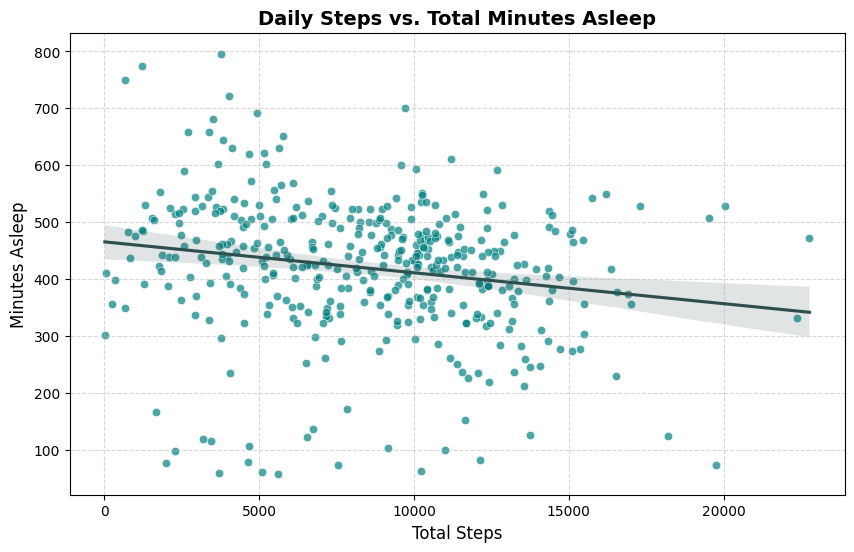

In [49]:
# Visualizing Steps vs. Minutes Asleep
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_df, x='TotalSteps', y='TotalMinutesAsleep', alpha=0.7, color='teal')

# Adding a trend line
sns.regplot(data=combined_df, x='TotalSteps', y='TotalMinutesAsleep', scatter=False, color='darkslategray')

plt.title('Daily Steps vs. Total Minutes Asleep', fontsize=14, fontweight='bold')
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Minutes Asleep', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Cell 11: Bar Chart - Average Hourly Steps

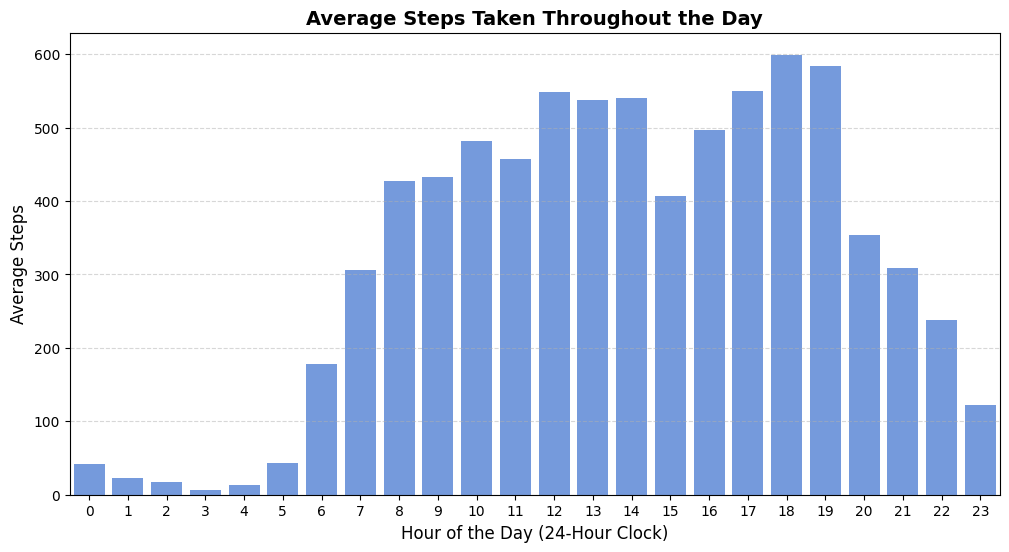

In [50]:
# Calculate and Visualize Average Hourly Steps
import matplotlib.pyplot as plt
import seaborn as sns

# Group by the 'Hour' column already engineered and find the mean
hourly_capsule = hourly_steps.groupby('Hour')['StepTotal'].mean().reset_index()

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_capsule, x='Hour', y='StepTotal', color='cornflowerblue')

plt.title('Average Steps Taken Throughout the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

Cell 12: Aggregate Activity and Sleep by Day of Week

In [51]:
# Analyze Activity and Sleep by Day of the Week

# Create a chronologically ordered Day of Week column
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
combined_df['DayOfWeek'] = pd.Categorical(combined_df['Date'].dt.day_name(), categories=day_order, ordered=True)

# Group data by DayOfWeek and find the averages
weekday_summary = combined_df.groupby('DayOfWeek', observed=False)[['TotalSteps', 'TotalMinutesAsleep']].mean().reset_index()

print("--- Average Steps and Sleep by Day of the Week ---")
display(weekday_summary.round(2))

--- Average Steps and Sleep by Day of the Week ---


,DayOfWeek,TotalSteps,TotalMinutesAsleep
0,Monday,9273.22,419.50
1,Tuesday,9182.69,404.54
2,Wednesday,8022.86,434.68
3,Thursday,8183.52,401.30
4,Friday,7901.40,405.42
5,Saturday,9871.12,419.07
6,Sunday,7297.85,452.75


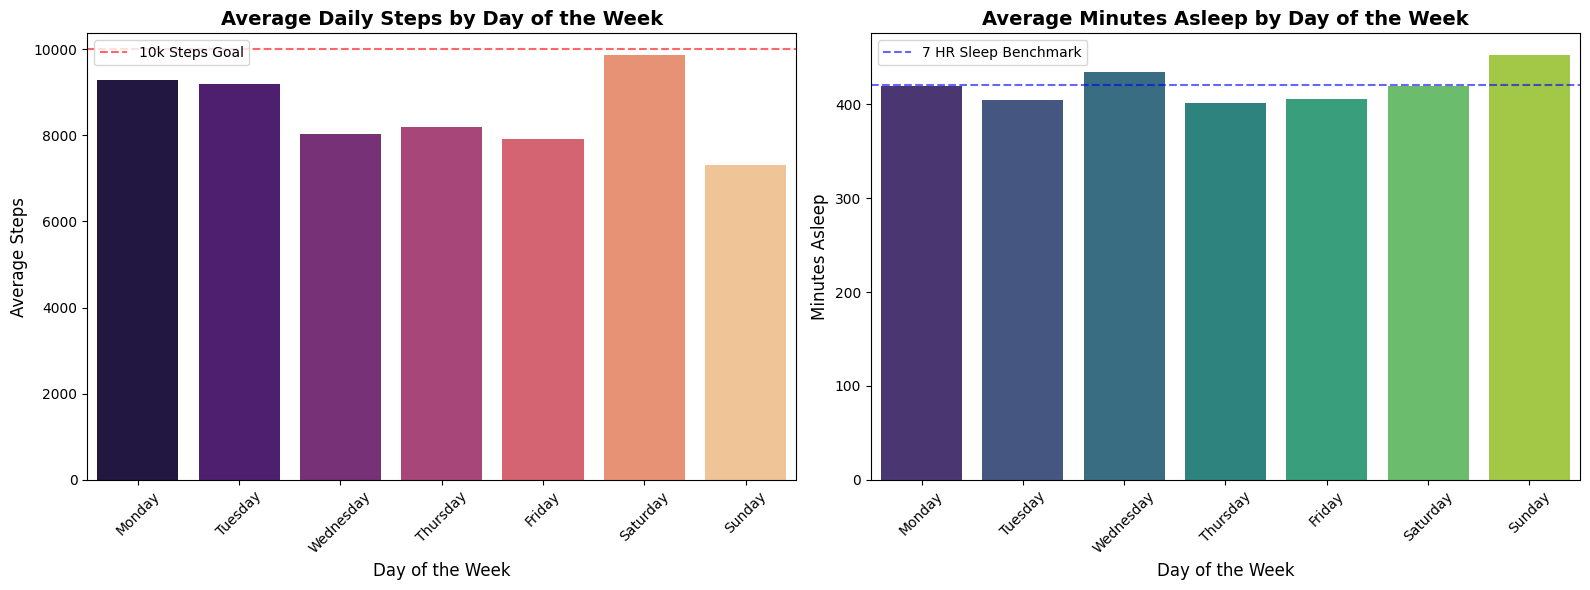

In [52]:
# Visualize Day of the Week Trends
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 1x2 grid for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Average Steps by Day of Week
sns.barplot(data=weekday_summary, x='DayOfWeek', y='TotalSteps', ax=axes[0], palette='magma', hue='DayOfWeek', legend=False)
axes[0].set_title('Average Daily Steps by Day of the Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of the Week', fontsize=12)
axes[0].set_ylabel('Average Steps', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
# Add CDC 10k step benchmark line
axes[0].axhline(y=10000, color='red', linestyle='--', alpha=0.6, label='10k Steps Goal')
axes[0].legend()

# Chart 2: Average Sleep Minutes by Day of Week
sns.barplot(data=weekday_summary, x='DayOfWeek', y='TotalMinutesAsleep', ax=axes[1], palette='viridis', hue='DayOfWeek', legend=False)
axes[1].set_title('Average Minutes Asleep by Day of the Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].set_ylabel('Minutes Asleep', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
# Add CDC 7-hour sleep benchmark line (7 hours = 420 minutes)
axes[1].axhline(y=420, color='blue', linestyle='--', alpha=0.6, label='7 HR Sleep Benchmark')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
import os
from google.colab import drive

# Open the secure gateway to Google Drive
# drive.mount('/content/drive')

# Define absolute corporate file path on Drive
# (Feel free to change 'Bellabeat_Case_Study' to match your actual root folder name)
target_directory = '/content/drive/MyDrive/Bellabeat_Case_Study/02_Clean_Data'

# Create the '02_Clean_Data' directory if it doesn't exist yet
os.makedirs(target_directory, exist_ok=True)

# Stream clean DataFrames directly into permanent cloud repository
combined_df.to_csv(f'{target_directory}/daily_activity_sleep_clean.csv', index=False)
hourly_steps.to_csv(f'{target_directory}/hourly_steps_clean.csv', index=False)

print("\n" + "="*60)
print(f"PIPELINE SECURED: Clean data permanently synced to:\n{target_directory}")
print("="*60)


PIPELINE SECURED: Clean data permanently synced to:
/content/drive/MyDrive/Bellabeat_Case_Study/02_Clean_Data
